# 02 - Validación del conjunto curado de textiles andinos (The Met)

Este notebook revisa los resultados del pipeline de curaduría aplicado a objetos recuperados desde la API de The Metropolitan Museum of Art.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [2]:
df_candidatos = pd.read_csv("../data/processed/met_candidatos_normalizados.csv")
df_curado = pd.read_csv("../data/processed/met_textiles_curado.csv")

print("Candidatos:", len(df_candidatos))
print("Curados:", len(df_curado))

Candidatos: 432
Curados: 291


In [3]:
df_candidatos["estado_curacion"].value_counts(dropna=False)

estado_curacion
aceptado_textil        274
excluido_no_textil     132
revision_manual         17
excluido_sin_imagen      9
Name: count, dtype: int64

In [4]:
df_candidatos["clasificacion_original"].value_counts(dropna=False).head(20)

clasificacion_original
Textiles-Woven           184
Metal-Ornaments           47
Textiles-Costumes         46
Textiles-Implements       32
Textiles-Featherwork      21
Ceramics-Containers       17
Textiles                  14
Textiles-Non-Woven        12
Wood-Containers            7
Textiles-Sculpture         7
Wood-Implements            7
Sculpture-Sheet metal      6
Feathers-Costumes          4
Metal-Implements           4
Wood-Sculpture             4
Bone/Ivory-Implements      4
Metal-Containers           2
Stone-Sculpture            2
Bone/Ivory-Ornaments       2
NaN                        2
Name: count, dtype: int64

In [5]:
df_curado["material_original"].value_counts(dropna=False).head(20)

material_original
Camelid hair                           141
Camelid hair, cotton                    45
Cotton                                  21
Cotton, camelid hair                    13
Bone                                    11
Cotton, feathers                        10
Camelid fiber                            8
Feathers on cotton, camelid hair         6
Cotton, paint                            5
Wood                                     5
Feathers, cotton, camelid hair           3
Cotton, pigment                          2
Camelid hair, feathers                   2
Cotton, refined iron earth pigments      1
Camelid hair, tapestry-weave             1
Camelid wool                             1
Cotton, camelid hair, and dye            1
Camelid and cotton fibers                1
Camelid fiber, cotton                    1
Camelid hair, silk                       1
Name: count, dtype: int64

In [6]:
df_curado[[
    "titulo_original",
    "titulo_es_sugerido",
    "clasificacion_original",
    "material_original",
    "puntaje_textil",
    "estado_curacion"
]].head(30)

,titulo_original,titulo_es_sugerido,clasificacion_original,material_original,puntaje_textil,estado_curacion
0,Tunic fragment,Túnica textil,Textiles-Woven,"Camelid hair, cotton",18,aceptado_textil
1,Tunic Fragment,Túnica textil,Textiles-Woven,"Camelid hair, cotton",18,aceptado_textil
2,Sash Fragment,Fragmento textil,Textiles-Woven,Cotton,18,aceptado_textil
3,Sash Fragments,Fragmento textil,Textiles-Woven,Cotton,18,aceptado_textil
4,Sash Fragments,Fragmento textil,Textiles-Woven,Cotton,18,aceptado_textil
5,Headband,Banda o vincha textil,Textiles-Woven,Camelid hair,18,aceptado_textil
6,Sash Fragment with Fringe,Fragmento textil,Textiles-Woven,Camelid hair,18,aceptado_textil
7,Tapestry Fragment,Fragmento textil,Textiles-Woven,Camelid hair,18,aceptado_textil
8,Headband,Banda o vincha textil,Textiles-Woven,Camelid hair,18,aceptado_textil
9,Tunic with Diamond Band,Túnica textil,Textiles-Woven,"Camelid hair, cotton",18,aceptado_textil


In [7]:
image_dir = Path("../outputs/samples/met_curado")
image_paths = sorted(image_dir.glob("*.jpg"))

print("Imágenes disponibles:", len(image_paths))
image_paths[:10]

Imágenes disponibles: 40


[WindowsPath('../outputs/samples/met_curado/met_textil_307677.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307679.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307683.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307851.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307852.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307853.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307959.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_307991.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_308017.jpg'),
 WindowsPath('../outputs/samples/met_curado/met_textil_308018.jpg')]

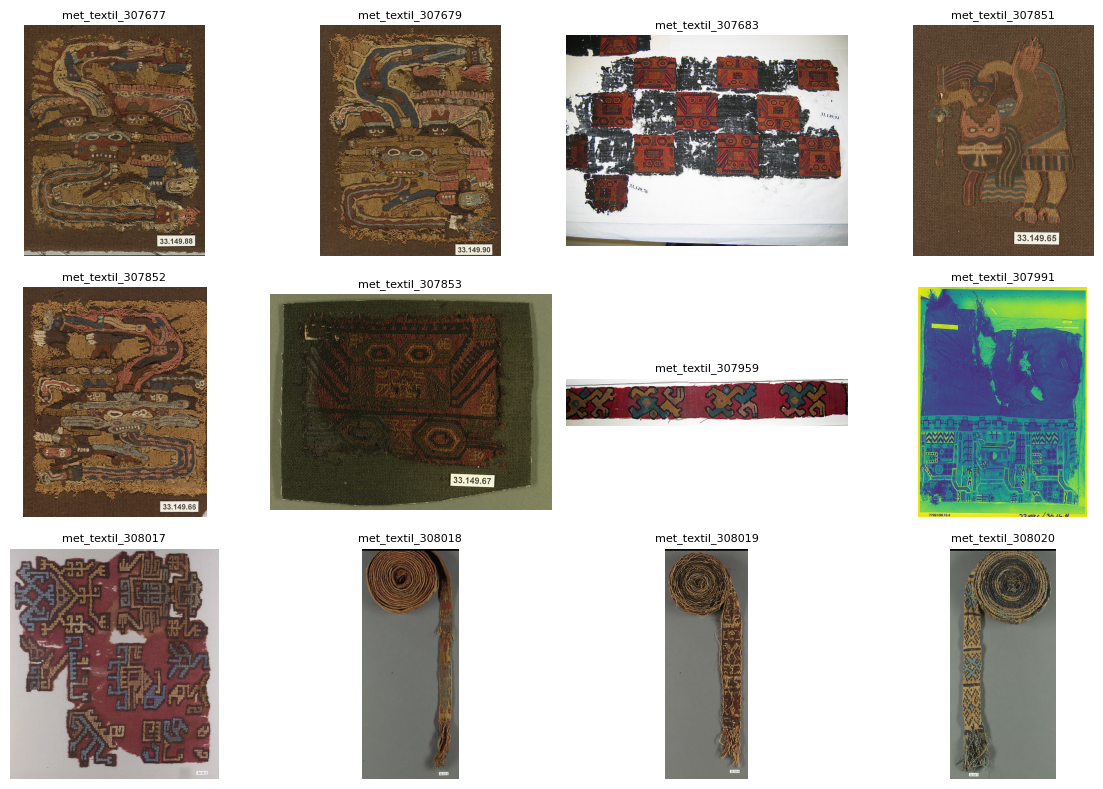

In [8]:
n = min(12, len(image_paths))

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(image_paths[:n]):
    img = Image.open(image_path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_path.stem, fontsize=8)

plt.tight_layout()
plt.show()